# EEG Based Sleep Staging

**What is Sleep Staging?**

Sleep staging is the process of classifying sleep into distinct physiological states based on neurophysiological recordings, primarily electroencephalography (EEG). This classification is fundamental to understanding sleep architecture and diagnosing sleep disorders.

**The Five Sleep Stages:**

1. **Wake (W)**: Active consciousness with eyes open or closed, characterized by high-frequency, low-amplitude EEG activity (alpha and beta rhythms when relaxed).

2. **N1 (NREM Stage 1)**: Light sleep transition from wakefulness. EEG shows theta activity (4-8 Hz) and disappearance of alpha rhythms. Easily disrupted by external stimuli.

3. **N2 (NREM Stage 2)**: Consolidated light sleep accounting for ~50% of total sleep time. Distinguished by sleep spindles (11-16 Hz bursts in the sigma band) and K-complexes (sharp negative deflections followed by positive components).

4. **N3 (NREM Stage 3 / Slow-Wave Sleep)**: Deep restorative sleep dominated by high-amplitude delta waves (<4 Hz). Critical for physical restoration, immune function, and memory consolidation. Difficult to awaken from.

5. **REM (Rapid Eye Movement)**: Paradoxical sleep with high-frequency, low-amplitude EEG resembling wakefulness, but with muscle atonia and rapid eye movements. Primary stage for vivid dreaming and emotional memory processing.

The goal of sleep staging is to classify sleep stages (Wake, N1, N2, N3, REM) from EEG data. The sampling unit is an **epoch** (typically 30 seconds), and for each epoch we have a feature vector of powers at discrete frequencies. The challenge lies in capturing subtle spectral signatures that distinguish stages while generalizing across subjects with different age, sex, and neurophysiology.

## Your work:

You have access to a dataset of 20 subjects. Each subject has recordings from 4 different PSG channels Fpz-Cz, Pz-Oz, EOG and EMG ( in this order in the array ).

Use subjects from 0 to 14 as training subjects and keep subjects 15 to 19 as testing subjects.

Your final objective is to deploy a machine learning model capable of staging sleep epochs into the 5 different sleep stages, from Wake to REM.

The project is divided in 2 parts: (1) Data Preparation and (2) Model Deployment. In part (1) you will build a workflow to clean the signal from channels artifacts, filtering and feature extraction. In part (2) you will use the training data to deploy a Machine Learning model in sleep staging and test its performance on an unseen slice of subjects ( testing data ).

In [1]:
# Imports
%matplotlib inline
import numpy as np
import torch
from tqdm import tqdm
from matplotlib import pyplot as plt
import os

from scipy.signal import welch
from typing import List, Tuple

from sklearn.decomposition import FastICA
from scipy.signal import butter, sosfiltfilt

import warnings
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# constants

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STAGES = ["Wake", "N1", "N2", "N3", "REM"]
STAGE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

CHANNELS = ["Fpz-Cz", "Pz-Oz", "EOG", "EMG"]
SUBJECTS = np.arange(20)
BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

fs = 100

In [4]:
# provided utiity functions
def plot_subjects_features(
    n_subjects: int,
    X: List[np.array], y: List[np.array],
    ncol: int = 2,
    nrows: int = 1,
    figsize: Tuple[int, int] = (15, 6),
) -> None:
    """
    Plot mean PSD features per sleep stage for multiple subjects.

    Parameters
    ----------
    n_subjects : int
        Number of subjects to plot (must be <= ncol * nrows).
    X : List[Tuple[np.ndarray, np.ndarray]]
        List where each element corresponds to one subject and is a tuple:
        (features, freqs)
        features: shape (n_epochs, n_freq_bins) power spectral densities (e.g. µV²/Hz).
        freqs: shape (n_freq_bins,) frequency axis in Hz.
    y : List[np.ndarray]
        List of arrays of integer stage labels per epoch for each subject.
        Each array shape: (n_epochs,). Labels must map 0..len(STAGES)-1.
    ncol : int, default=2
        Number of subplot columns.
    nrows : int, default=1
        Number of subplot rows.
    figsize : Tuple[int, int], default=(15, 6)
        Matplotlib figure size.

    Returns
    -------
    None
        Displays the matplotlib figure with one subplot per subject.

    Notes
    -----
    - Y-axis label uses µV²/Hz (dB); ensure your input is already in desired scale.

    Example
    -------
    # Prepare data for 2 subjects
    subj_features_0, freqs_0 = features_subject_0, freqs
    subj_features_1, freqs_1 = features_subject_1, freqs
    X_plot = [(subj_features_0, freqs_0), (subj_features_1, freqs_1)]
    y_plot = [stages_subject_0, stages_subject_1]

    plot_subjects_features(
        n_subjects=2,
        X=X_plot,
        y=y_plot,
        ncol=2,
        nrows=1,
        figsize=(10, 4),
    )
    """

    fig, axs = plt.subplots(
        ncols=ncol, nrows=nrows, sharey="row", sharex=True, figsize=figsize
    )
    axs = axs.flatten()

    for i in tqdm(range(n_subjects), desc="Reading data"):
        features, freqs = X[i]
        stages = y[i]

        ax = axs[i]
        ax.set_title(f"Subject {i + 1}")

        for stage_id, stage in enumerate(STAGES):
            psd_stage = features[stages == stage_id]

            mean_psd = np.mean(psd_stage, axis=0)

            x_freqs = freqs
            mean_psd = mean_psd

            ax.plot(
                x_freqs.astype(float),
                mean_psd,
                label=stage,
                color=STAGE_COLORS[stage_id],
                linewidth=0.5,
            )

        # lines dividing each band
        # suppress warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for band, (fmin, fmax) in BANDS.items():
                ax.axvline(fmin, color="k", linestyle="-.", linewidth=0.5)

                if band == "beta":
                    ax.axvline(fmax, color="k", linestyle="-.", linewidth=0.5)

                ax.text(
                    (fmin + fmax) / 2,
                    ax.get_ylim()[1] - 5,
                    f"$\{band}$",
                    horizontalalignment="center",
                    verticalalignment="top",
                    fontsize=8,
                    color="k",
                    alpha=0.7,
                )

        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

        if i >= (nrows - 1) * ncol:
            ax.set_xlabel("Frequency (Hz)")

        if i % ncol == 0:
            ax.set(ylabel="µV²/Hz (dB)")

        ax.set_xlim(0, 30)

    # Add legend to the last subplot
    handles = [plt.Line2D([0], [0], color=color, lw=2) for color in STAGE_COLORS]
    labels = STAGES
    axs[-1].legend(handles, labels, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

    return

<>:99: SyntaxWarning: invalid escape sequence '\{'
<>:99: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-3955643298.py:99: SyntaxWarning: invalid escape sequence '\{'
  f"$\{band}$",


## 1. Data Preparation

### Task 0 — Data Loading

Goal: load and inspect the provided PSG recordings and prepare them for the preprocessing pipeline.

Code already provided here, just run the cell !


In [5]:
X , y = [], []

# BASE = "..."

for i in tqdm(SUBJECTS, desc = "Fetching data"):
    # load the data
    # signal = torch.load(f"{BASE}/data/signals/subject_{i}.pt".format(i) ) # I used this line to load the data from google colab
    # stages = torch.load(f"{BASE}/data/stages/subject_{i}.pt".format(i) )
    signal = torch.load( "data/signals/subject_{}.pt".format(i) )
    stages = torch.load( "data/stages/subject_{}.pt".format(i) )

    X.append( signal.float().numpy() )
    y.append( stages.long().numpy() - 1)

print( "Data Loaded." )
print( "Subject 0 shape: ", X[0].shape, " Subject 0 stages shape: ", y[0].shape )

print( "Shape 1 : Number of windows \nShape 2 : Number of channels (Fpz-Cz Pz-Oz EOG EMG)\nShape 3 : Number of time samples per window ( 30s x 100 fs ), units: V" )

Fetching data: 100%|██████████| 20/20 [00:45<00:00,  2.25s/it]

Data Loaded.
Subject 0 shape:  (841, 4, 3000)  Subject 0 stages shape:  (841,)
Shape 1 : Number of windows 
Shape 2 : Number of channels (Fpz-Cz Pz-Oz EOG EMG)
Shape 3 : Number of time samples per window ( 30s x 100 fs ), units: V


### Task 1 — Visualize a single epoch

Goal: provide a compact plotting routine to inspect raw epochs for visualization of the different channels signals.

Deliverables:
- Implement code that, given `subject` and `epoch` indices, plots a figure with 4 stacked subplots (one per channel in order: Fpz-Cz, Pz-Oz, EOG, EMG).
- The figure title must include the subject id, epoch index, and the annotated stage name (e.g. `Stage: Wake`).
- Add y-axis labels (µV) for clarity and a shared x-axis labelled in seconds.
- Discuss visible patterns characterizing each sleep stage in markdown specifying the epoch id and subject id they refer to.

In [6]:
# set subject and epoch
epoch = 777
subject = 6

In [7]:
# write the plotting routine here

def plot_epoch(subject, epoch, X, y, fs=100):
  signal = X[subject][epoch]
  stage = STAGES[y[subject][epoch]]

  t = np.arange(signal.shape[1]) / fs # 30s
  fig, axs = plt.subplots(4, 1)

  fig.suptitle(f"Subject {subject}, Epoch {epoch}, Stage: {stage}")

  for i, ax in enumerate(axs):
      ax.plot(t, signal[i] * 1e6)
      ax.set_ylabel("µV")
      ax.set_title(CHANNELS[i])

  plt.xlabel("Time (s)")
  plt.tight_layout()
  plt.show()

for i in range(5):
  print("10 Stage epoch indexes for stage", STAGES[i], ":", (np.where(y[subject] == i))[0][:10])

10 Stage epoch indexes for stage Wake : [0 1 2 3 4 5 6 7 8 9]
10 Stage epoch indexes for stage N1 : [ 60  61  62  63  64  65  70 117 118 119]
10 Stage epoch indexes for stage N2 : [66 67 68 69 71 72 73 74 75 76]
10 Stage epoch indexes for stage N3 : [168 172 173 174 175 176 177 178 179 180]
10 Stage epoch indexes for stage REM : [249 250 251 252 253 254 255 256 257 258]


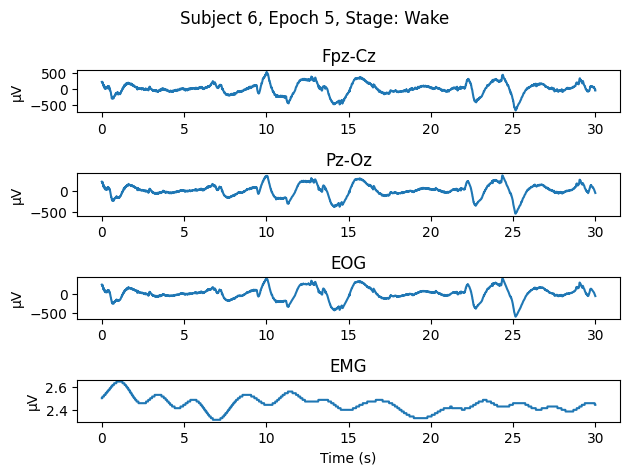

In [10]:
# I will try to find an example for every sleep stage so I will later point to them after explaining some characteristic patterns in each sleep stage
# the subject stays 6
plot_epoch(subject, 5, X, y)

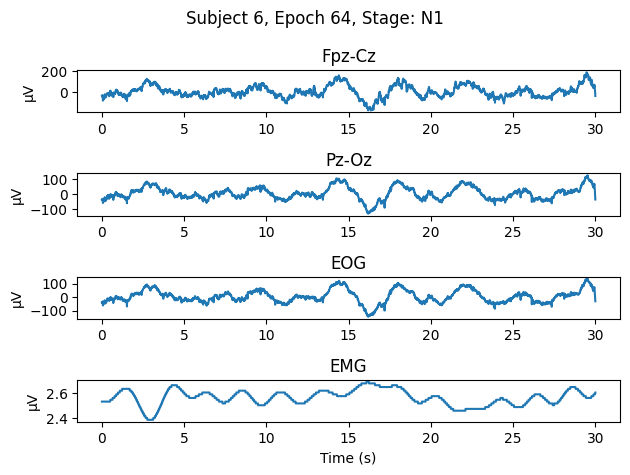

In [128]:
plot_epoch(subject, 64, X, y)

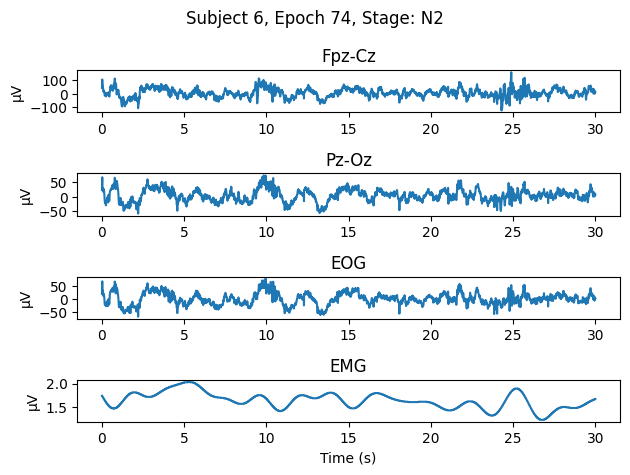

In [135]:
plot_epoch(subject, 74, X, y)

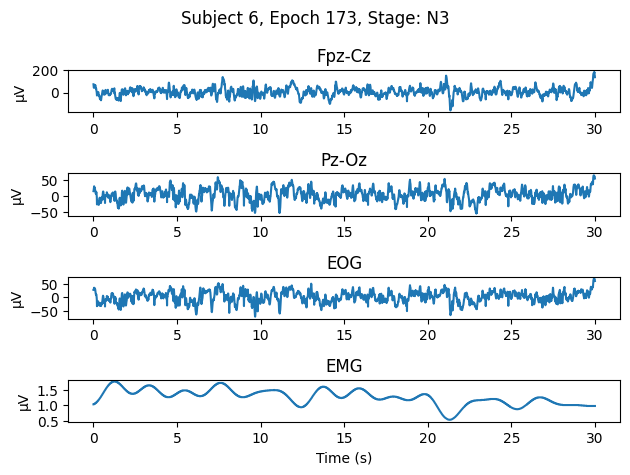

In [148]:
plot_epoch(subject, 173, X, y)

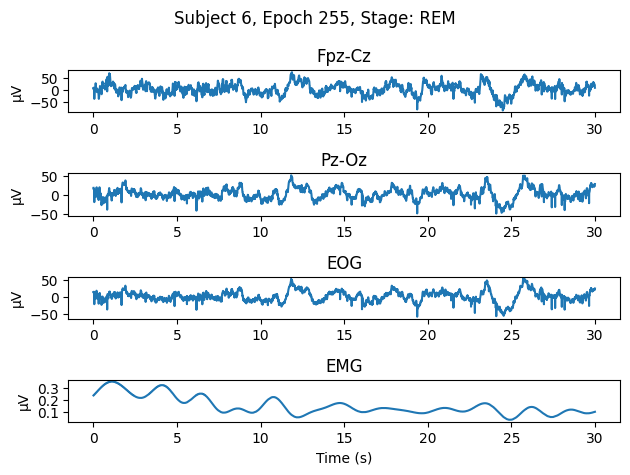

In [138]:
plot_epoch(subject, 255, X, y)

write the discussion in markdown here


### Discussion:

The following discussion points to the plots shown above for subject 6.

**WAKE: Epoch 5**
The wake stage is typically represented by high frequency and low amplitude signal, representing mostly beta and alpha wave. However in this subject epoch 5, the EEG channels show fast, irregular activity with relatively high peak-to-peak amplitude, which is mainly caused by eye movement and muscle artefacts rather than synchronized brain rhythms. The EOG shows frequent eye movements, and the EMG has the highest amplitude, reflecting active muscle tone.

**N1: Epoch 64**
In this stage the EEG activity becomes slower and more regular compared to wake with reduced amplitude and increased theta content. Visible in the plot as well but with visible EOG artifacts in the EEG again. The EOG shows slow, smooth deflections, consistent with slow rolling eye movements durign sleep and there is still some muscle tone present.

**N2: Epoch 74**
This stage has "medium" amplitude activity dominated by theta frequencies with brief bursts of faster oscillations that usually correspond to sleep spindles. The sleep spindles in the plot can be spotted around the 25 second. Also in this stage K-complexes might be present. The EOG is slower indicating minimal eye movement and the EMG is a little bit reduced.

**N3: Epoch 173**
This is the deep sleep and it is characterized with larger amplitude and slower fluctuations, mainly representing the delta power. This waveform appears synchronized and less irregular than in lighter sleep stages, but it can be clearly seen that there is EOG artefacts present in the EEG signal. The EOG channel here remains quiet, and the EMG amplitude is low but still present.

**REM: Epoch 255**
In this epoch the amplitude is even lower and we have mixed frequencies, showing wakefulness but without the same level of muscle activity. The EOG channel shows distinct rapid deflections, indicating bursts of rapid eye movements and the EMG signal is suppressed, showing the lowest amplitude across al stages.

### Task 2 — Removal of EOG / EMG artefacts from EEG

Goal: use ICA to separate reference artefact channels (EOG, EMG) from EEG and produce a reproducible artefact-removal step for the pipeline.

Deliverables:
- Fit a reproducible FastICA model on the training subjects (subjects 0–14). Document which data were concatenated and the final training shape used for ICA.
- Explain and implement the correct reshaping required by scikit-learn ICA.

In [8]:
# fit the ICA model
# take care of ICA randomness
# Note: ICA fit function takes as input n_samples x n_channels data.

X_train = []

for subject in range(15): #0-14
  data = X[subject]
  data = np.swapaxes(data, 1, 2) #swap channels with samples
  data = data.reshape(-1, 4) # multiply epochs with samples
  X_train.append(data)

X_train = np.vstack(X_train)

In [9]:
print(X_train.shape) #total samples across subjects, 4

(47280000, 4)


In [10]:
ica = FastICA(
    n_components=4,
    random_state=RANDOM_SEED,
    whiten='unit-variance',
    max_iter=1000,
)

In [11]:
ica.fit(X_train)

FastICA(max_iter=1000, n_components=4, random_state=42)

### How should you reshape the data properly ?
In order to reshape the data properly we need to first switch the channels with the samples and then  we can multiply the epochs with the samples because we need all samples to feed the ICA  since we have 3000 dimensional samples, meaning 30s * 100Hz, we multiply them with the epochs  and we have 47280000 total samples across subjects.

### Task 2.1 — Visual inspection of ICA components

Goal: inspect and nominate independent components that capture ocular and muscular artefacts.

Deliverables:
- For a chosen subject and epoch, plot all its ICA transformed components alongside the original EOG and EMG channels so associations are visually evident.

Note:
- Take care of signal reshaping before and after ICA transformation

Additional Questions:
- Identify which components are likely EOG-related and which are EMG-related. Provide a short rationale for each identification.
- Discuss the effect of including vs excluding EOG/EMG channels from ICA input.

In [12]:
subject = 6
epoch = 5

raw = X[subject][epoch]
raw = raw * 1e6          # shape (4, 3000)
raw_T = raw.T                    # shape (3000, 4) -> needed for ICA

S = ica.transform(raw_T)           # shape (3000, 4) -> components
S = S.T                             # shape (4, 3000) for plotting

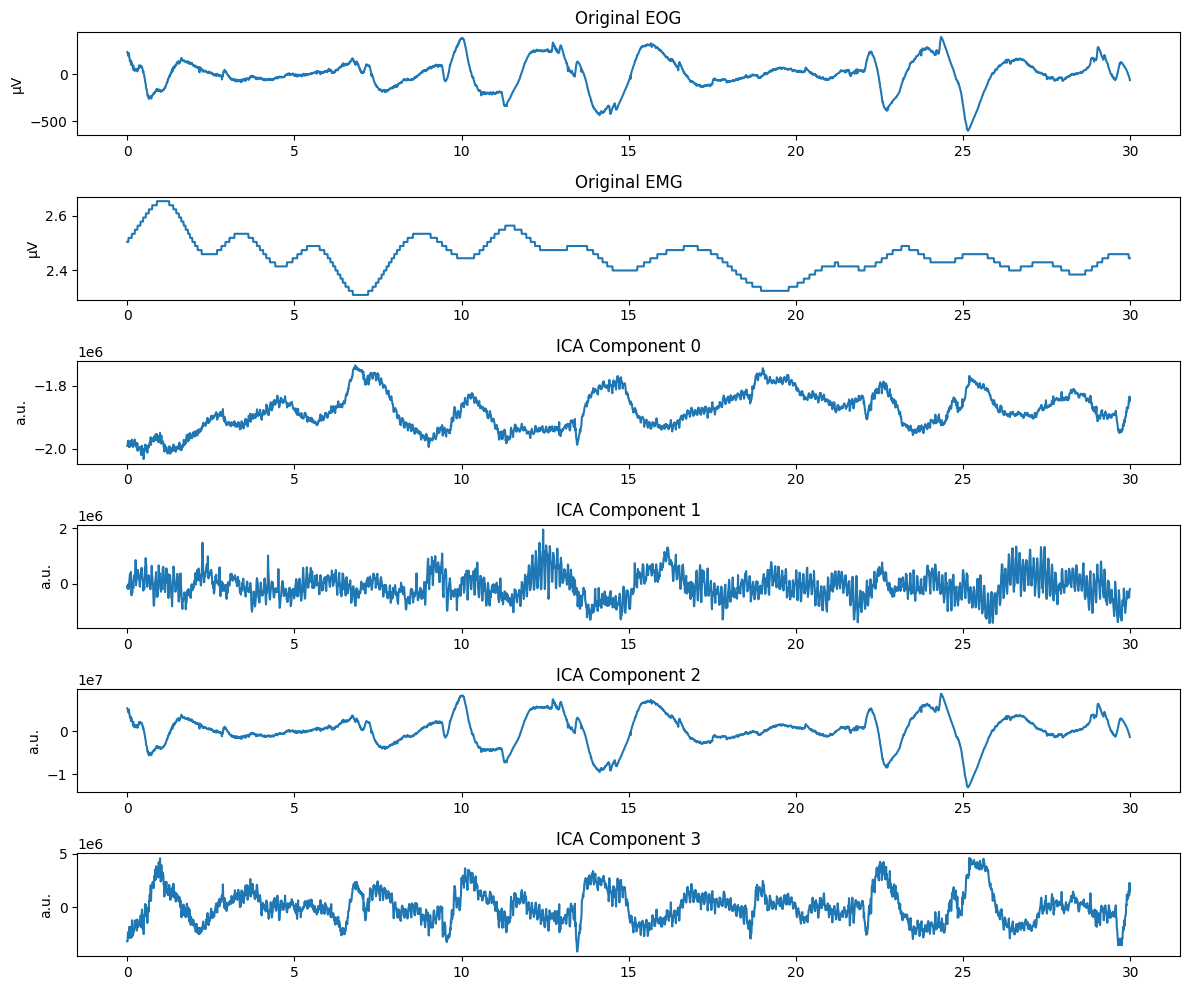

In [13]:
fig, axs = plt.subplots(6, 1, figsize=(12, 10))

t = np.arange(raw.shape[1]) / fs

# original EOG & EMG
axs[0].plot(t, raw[2])
axs[0].set_title("Original EOG")
axs[0].set_ylabel("µV")

axs[1].plot(t, raw[3])
axs[1].set_title("Original EMG")
axs[1].set_ylabel("µV")

# ICA components
for k in range(4):
    axs[k+2].plot(t, S[k])
    axs[k+2].set_title(f"ICA Component {k}")
    axs[k+2].set_ylabel("a.u.")

plt.tight_layout()
plt.show()

### Discussion

1. Identify which components are likely EOG-related and which are EMG-related. Provide a short rationale for each identification.
 - ICA component 2 shows large and slow deflections with a waveform shape that is close to the original EOG channel so we can say that component 2 is likely related. Moreover, component 0 seems to be EMG related because it represents very slow wave as we have in the EMG signal.
2. Discuss the effect of including vs excluding EOG/EMG channels from ICA input.
- If EOG/EMG are included the ICA algorithm will clearly see where the eye movement and muscle artefacts are coming from, those channels will become well isolated components and if we remove those components, EEG will become clearer. On the other hand, if we exclude EOG/EMG from ICA input, ICA will perform worse because the algorithm will have to guess where the artefacts come from by only using EEG. Therefore by **including** those channels in the ICA input the algorithm will become better, otherwise it would be less reliable and more subjective.

### Task 2.2 — Automatic ICA component elimination

Goal: implement a reproducible, automated procedure that nominates and removes ICA components associated with ocular (EOG) and muscular (EMG) artefacts and returns denoised EEG epochs.

Deliverables:
- Compute an association metric between each independent component and the reference artefact channels (EOG and EMG). Use Pearson correlation on concatenated component time series as metric.
- Define a deterministic selection rule (e.g., select the component with maximum absolute correlation ).
- After selecting EOG/EMG components, set their activity to zero and perform the inverse ICA transform to reconstruct denoised signals.
- Return de-mixed EEG channels (Fpz-Cz, Pz-Oz) in the original shape (n_epochs, n_channels=2, n_samples).

Additional Questions:
- Visualize the signal before and after applying ICA for sanity checking with a figure ( 2 rows: one for Fpz-Cz and one for Pz-Oz).
- On each row visualize the original signal and the de-mixed on top of each other with different colors.

In [14]:
# automatically identify artifact components using correlation with EOG and EMG channels

def identify_artifact_components(X_sub, ica):
    """
    X_sub: (n_epochs, 4, n_samples)
    returns: indices of EOG and EMG components
    """
    n_epochs, n_ch, n_samples = X_sub.shape

    X2d = np.swapaxes(X_sub, 1, 2).reshape(-1, 4) # (samples_total, 4)

    S = ica.transform(X2d)         # (T, 4)

    # original mixed signals reference
    eog_ts = X2d[:, 2]
    emg_ts = X2d[:, 3]

    # pearson correlation
    corr_eog = np.array([abs(np.corrcoef(S[:, k], eog_ts)[0, 1])
                         for k in range(S.shape[1])])
    corr_emg = np.array([abs(np.corrcoef(S[:, k], emg_ts)[0, 1])
                         for k in range(S.shape[1])])

    # deterministic rule: select component with max absolute correlation
    eog_idx = int(np.argmax(corr_eog))
    emg_idx = int(np.argmax(corr_emg))

    return eog_idx, emg_idx

def denoise_subject_with_ica(X_sub, ica, eog_idx, emg_idx):
    """
    Returns cleaned EEG (Fpz-Cz, Pz-Oz) with shape (n_epochs, 2, n_samples)
    """
    n_epochs, n_ch, n_samples = X_sub.shape

    X2d = np.swapaxes(X_sub, 1, 2).reshape(-1, 4) # (samples_total, 4)

    S = ica.transform(X2d)

    # we zero out artefacts
    S[:, eog_idx] = 0
    S[:, emg_idx] = 0

    X2d_clean = ica.inverse_transform(S) # back to mixed channel space

    X_clean = X2d_clean.reshape(n_epochs, n_samples, 4)
    X_clean = np.swapaxes(X_clean, 1, 2)

    return X_clean[:, :2, :]

In [15]:
# Apply the ICA transformation to both train and test data subject-wise
X_clean_all = []

for subj in SUBJECTS:
    print(f"Processing subject {subj}...")

    eog_idx, emg_idx = identify_artifact_components(X[subj], ica)
    X_clean_sub = denoise_subject_with_ica(X[subj], ica, eog_idx, emg_idx)

    X_clean_all.append(X_clean_sub)

print("All subjects denoised.")

Processing subject 0...
Processing subject 1...
Processing subject 2...
Processing subject 3...
Processing subject 4...
Processing subject 5...
Processing subject 6...
Processing subject 7...
Processing subject 8...
Processing subject 9...
Processing subject 10...
Processing subject 11...
Processing subject 12...
Processing subject 13...
Processing subject 14...
Processing subject 15...
Processing subject 16...
Processing subject 17...
Processing subject 18...
Processing subject 19...
All subjects denoised.


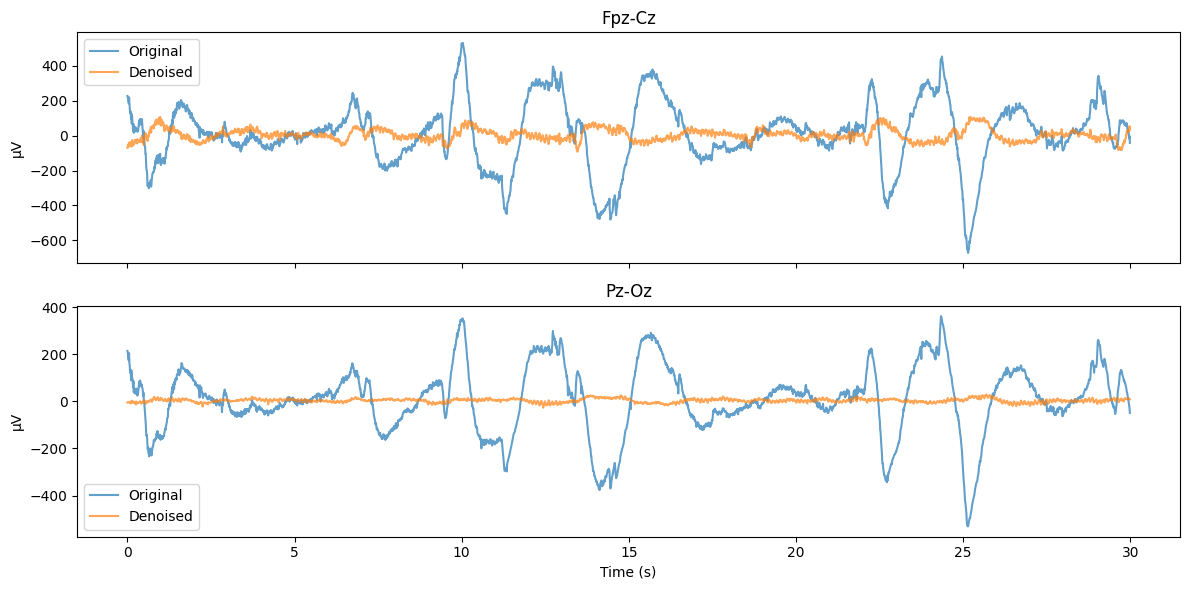

In [ ]:
# plot the denoised EEG signal before and after removing the identified components

subject = 6
epoch = 5

def plot_before_after(subject, epoch, X_raw, X_clean, fs=100):
    t = np.arange(X_raw[subject].shape[-1]) / fs

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    raw_uV = X_raw[subject][epoch] * 1e6
    clean_uV = X_clean[subject][epoch] * 1e6

    axs[0].plot(t, raw_uV[0], label="Original", alpha=0.7)
    axs[0].plot(t, clean_uV[0], label="Denoised", alpha=0.7)
    axs[0].set_title("Fpz-Cz")
    axs[0].set_ylabel("µV")
    axs[0].legend()

    axs[1].plot(t, raw_uV[1], label="Original", alpha=0.7)
    axs[1].plot(t, clean_uV[1], label="Denoised", alpha=0.7)
    axs[1].set_title("Pz-Oz")
    axs[1].set_ylabel("µV")
    axs[1].set_xlabel("Time (s)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_before_after(subject, epoch, X, X_clean_all)

### Task 3 — Signal Filtering

Goal: design and apply a filter that preserves EEG spectral content relevant for sleep staging while removing slow drifts and high-frequency noise.

Deliverables:
- Choose and justify filter parameters (type, passband, order). Suggestion: use scipy.signal.sosfiltfilt for numerical stability.
- Implement a reusable filter function and apply it to the selected EEG channel(s) for all subjects.
- Demonstrate the effect of filtering: plot an example epoch before and after filtering (time-domain) and show the PSD (Welch) before/after to confirm expected attenuation.

Additional Question:
- Should you filter before or after ICA artifacts removal  ?

In [17]:
# select a single EEG channel for sleep staging, e.g. Fpz-Cz
channel = 0   # 0 = Fpz-Cz, 1 = Pz-Oz

raw_signal = X_clean_all[subject][epoch, channel]   # denoised by ICA

# at this point we can proceed with signal filtering to isolate the important EEG bands and remove slow-drift or high frequency noise

def bandpass_filter(x, fs=100, f_low=0.5, f_high=30, order=4):
    sos = butter(order, [f_low, f_high], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, x)

filtered_signal = bandpass_filter(raw_signal)

I use here 4th order butterworth bandpass filter (0.5-30Hz) applied with zero-phase sosfiltfilt. This passband preserves the main EEG rhythms relevang for sleep staging, while the high-pass at 0.5 Hz removed slow drifts and the low-pass at 30 Hz suppresses high-frequency noirse and residual EMG activity.

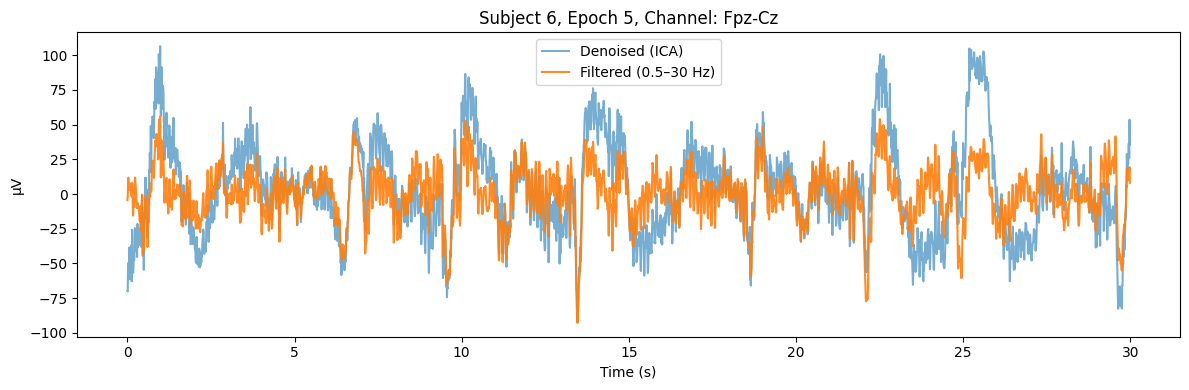

In [18]:
# plot the final denoised and filtered signal for a given subject and epoch vs original raw signal
fs = 100
t = np.arange(raw_signal.shape[-1]) / fs

raw_uV = raw_signal * 1e6
filtered_uV = filtered_signal * 1e6

plt.figure(figsize=(12,4))
plt.plot(t, raw_uV, label="Denoised (ICA)", alpha=0.6)
plt.plot(t, filtered_uV, label="Filtered (0.5–30 Hz)", alpha=0.9)
plt.xlabel("Time (s)")
plt.ylabel("µV")
plt.title(f"Subject {subject}, Epoch {epoch}, Channel: {CHANNELS[channel]}")
plt.legend()
plt.tight_layout()
plt.show()

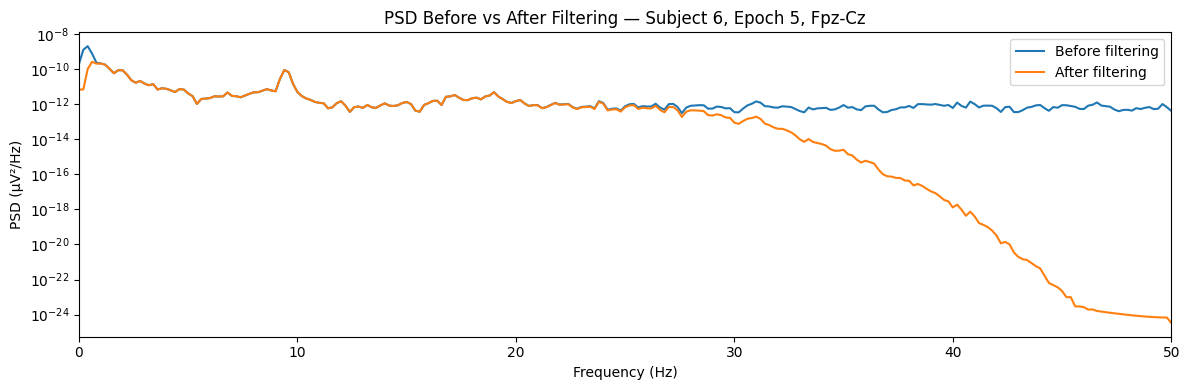

In [19]:
# PSD  (welch)
f_raw, P_raw = welch(raw_signal, fs=fs, nperseg=500)
f_filt, P_filt = welch(filtered_signal, fs=fs, nperseg=500)

plt.figure(figsize=(12,4))
plt.semilogy(f_raw, P_raw, label="Before filtering")
plt.semilogy(f_filt, P_filt, label="After filtering")
plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title(f"PSD Before vs After Filtering — Subject {subject}, Epoch {epoch}, {CHANNELS[channel]}")
plt.legend()
plt.tight_layout()
plt.show()

We should apply ICA first and then to apply the bandpass filter after artifact removal, because ICA needs access to the full spectral content of the signals to reliably separate independent sources.

### Task 4 — Feature Extraction

Goal: extract a compact set of spectral features from each epoch suitable for supervised sleep staging.

Deliverables:
- Compute power spectral density (PSD) features for each epoch using Welch's method and convert them to a suitable scale (dB). Return features shaped (n_epochs, n_freq_bins) per patient and the corresponding frequency vector.
- Optional (Bonus Points): propose additional features that may help staging. Should also other channels ( i.e. EOG and/or EMG ) be taken into consideration ?
- Provide summary visualization with the provided psd-feature plotting function and use box-plots for any other feature.

Additional Question:
- Is high/low/bandpass filtering needed if we remove the reduced frequencies afterwards during feature extraction? Why (not) ?

In [20]:
# extract features from the cleaned EEG signals

def extract_psd_features(X_clean_sub, fs=100, nperseg=300):
    """
    X_clean_sub: (n_epochs, 2, n_samples) *cleaned & filtered EEG for one subject
    returns:
        features: list of length 2, each entry shape (n_epochs, n_freq_bins)
        freqs: frequency vector returned by welch
    """
    n_epochs, n_ch, n_samples = X_clean_sub.shape
    psd_features = []

    for ch in range(n_ch):
        feats = []
        for ep in range(n_epochs):
            freqs, Pxx = welch(X_clean_sub[ep, ch], fs=fs, nperseg=nperseg)
            Pxx_dB = 10 * np.log10(Pxx + 1e-12)
            feats.append(Pxx_dB)
        psd_features.append(np.vstack(feats))

    return psd_features, freqs


# compute PSD features for all subjects
PSD_all = []     # each entry: [features_ch0, features_ch1]
freqs_all = None

for subj in tqdm(SUBJECTS, desc="Extracting PSD features"):
    feats, f = extract_psd_features(X_clean_all[subj])
    PSD_all.append(feats)
    freqs_all = f

# extract any other feature you may consider useful for sleep staging

def extract_bandpower(signal, fs, band):
    freqs, Pxx = welch(signal, fs=fs, nperseg=300)
    fmin, fmax = band
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(Pxx[mask], freqs[mask])

BANDPOWER_all = []

for subj in tqdm(SUBJECTS, desc="Extracting bandpower features"):
    Xsub = X_clean_all[subj]
    n_epochs = Xsub.shape[0]
    bp_feats = []

    for ep in range(n_epochs):
        epoch_bp = []
        for ch in [0,1]:    # EEG channels only
            for band in BANDS.values():
                epoch_bp.append(extract_bandpower(X_clean_all[subj][ep, ch], fs, band))
        bp_feats.append(epoch_bp)
    BANDPOWER_all.append(np.array(bp_feats))


Extracting bandpower features:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipython-input-2558806876.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[mask], freqs[mask])
Extracting bandpower features: 100%|██████████| 20/20 [05:00<00:00, 15.04s/it]


In [21]:
print("PSD features \n", type(PSD_all), len(PSD_all), PSD_all[0][0][0][0])
print("BANDPOWER features \n", type(BANDPOWER_all), len(BANDPOWER_all), BANDPOWER_all[0][0][0])

PSD features 
 <class 'list'> 20 -106.82846
BANDPOWER features 
 <class 'list'> 20 3.7744520356430833e-10


Reading data: 100%|██████████| 2/2 [00:00<00:00, 123.01it/s]


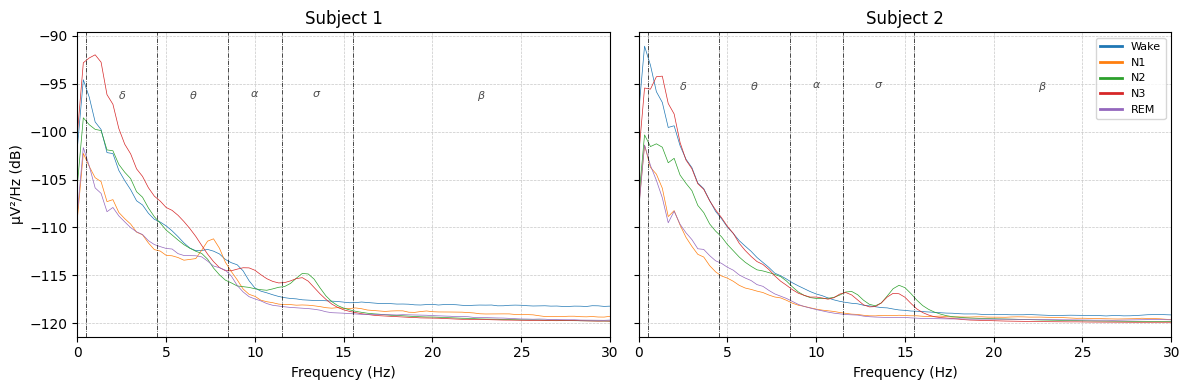

In [22]:
# now visualize the extracted features for a given subject and epoch
# you can use the plot_subjects_features to visualize the psd features
# plot_subjects_features( n_subjects = 2, X = ... , y = ... , ncol=2, nrows=1, figsize=(6, 6) )


X_plot = []
y_plot = []

for subj in range(2):            # first two subjects
    X_plot.append((PSD_all[subj][0], freqs_all))   # channel 0 PSD
    y_plot.append(y[subj])

plot_subjects_features(
    n_subjects=2,
    X=X_plot,
    y=y_plot,
    ncol=2,
    nrows=1,
    figsize=(12, 4)
)

In [23]:
BANDPOWER_REL_all = [] # normalize bandpower per epoch for more visual representation

for subj in range(len(BANDPOWER_all)):
    bp = BANDPOWER_all[subj]                 # (n_epochs, n_features)
    bp_sum = bp.sum(axis=1, keepdims=True)   # (n_epochs, 1)

    bp_rel = bp / (bp_sum + 1e-12)            # to avoid division by zero
    BANDPOWER_REL_all.append(bp_rel)

bp_rel = BANDPOWER_REL_all[subject]
labels = y[subject]

band_names = list(BANDS.keys())
channels = ["Fpz-Cz", "Pz-Oz"]

rows = []
for ep in range(bp_rel.shape[0]):
    idx = 0
    for ch in channels:
        for band in band_names:
            rows.append({
                "Stage": STAGES[labels[ep]],
                "Channel": ch,
                "Band": band,
                "RelativePower": bp_rel[ep, idx]
            })
            idx += 1

df_rel = pd.DataFrame(rows)

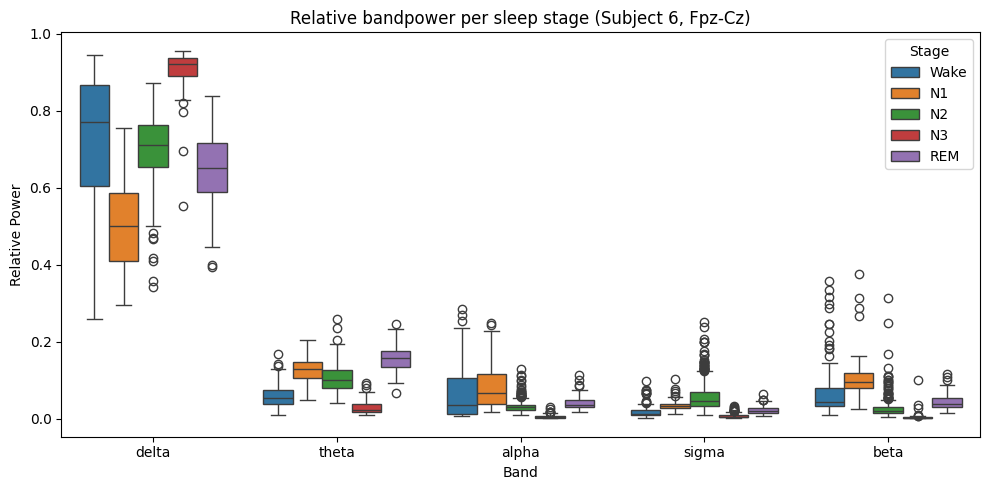

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_rel[df_rel["Channel"] == "Fpz-Cz"],
    x="Band",
    y="RelativePower",
    hue="Stage"
)
plt.title("Relative bandpower per sleep stage (Subject 6, Fpz-Cz)")
plt.ylabel("Relative Power")
plt.tight_layout()
plt.show()

### Discussion:

1. Is high/low/bandpass filtering needed if we remove the reduced frequencies afterwards during feature extraction? Why (not) ?
- Yes, filtering is still necessary. Although PSD-based feature extraction focuses on specific frequency bands, unfiltered signals still contain slow drifts and high-frequency noise that can leak into the estimated spectrum due to windowing effects and finite-resolution Fourier transforms.
Band-pass filtering before PSD computation improves numerical stability, reduces spectral leakage, and ensures that extracted features more accurately represent physiological EEG activity.
2. Additional spectral features
- I decided to extract bandpower in addition to the PSD, by integrating the PSD over canonical EEG freq. bands (delta, theta, alpha, sigma, beta). The bandpower provides a compact and physiologically meaningfull representation of each epoch by directly reflecting known sleep stage characteristics such as increased delta power in N3 and similar.
3. Use of EOC and/or EMG
- These channels should not be taken into consideration because they might reintroduce artefacts into the EEG based representations.

## 2. Machine Learning Model deployment
In this section you need to deploy a single machine learning model ( from sklearn ), and evaluate its performances on an unknown set of subjects ( id from 15 to 20 ). This evaluation needs to be done using the sklearn classification report and the confusion matrix.

To set the type of model you want to deploy and to decide its hyperparameters you are asked to build a cross-validation ( leave-one-subject-out ) and evaluate a set of metrics. The model maximising those metrics needs to be chosen to be deployed and tested on the testing set.

The results of the cross validation should be a table (pandas.DataFrame) including all the trials of the different pipelines, models and hyperparameters you tried during this phase. Any combination not explicitly listed in the table cannot be used as a motivation for the discussion during the oral exam, so be sure to include all the trials you made.

An exhaustive cross validation should include
- Feature aggregation mechanisms for dimensionality reduction
- Different sklearn models
- Different hyperparameters of the same model

In [25]:
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from tqdm import tqdm

# preprocessing pipeline
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

from sklearn.base import clone
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as tree
from sklearn.svm import SVC

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)

from pickle import dump, load

from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

### Task 1 — Define scoring, classifiers and cross-validation split

Goal: define the evaluation metrics, candidate classifiers, and implement a subject-wise cross-validation split suitable for PSG data.

Deliverables:
- Select and justify a set of scoring metrics and document their rationale.
- List all the different preprocessing steps configurations ( e.g. dimensionality reduction, scaling ).
- List the classifiers and hyperparameters.
- Implement the leave-one-subject-out cross-validation (LOSO) split using a `groups` array so folds are subject-separated. Note: you must only use training data during cross-validation.

Note:
- The comparison of different preprocessing steps should include: manual dimensionality reduction vs automatic ( e.g. averaging the EEG bands vs PCA with different number of components )
- Choosing the best classifier should also include varing its parameters ( e.g. for K-NN varying the number of K ).


In [ ]:
SUBJECTS_TRAIN = np.arange(15)   
SUBJECTS_TEST = np.arange(15, 20)  

In [27]:
# Select and justify a set of scoring metrics and document their rationale.
# metrics are computed manually but this dictionary is here just for documentation purposes
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

### Evaluation Metrics

Since this is a **multi-class classification problem** with **imbalanced sleep stages**, the models will be evaluated using the following metrics:

- **Accuracy**: the overall proportion of correctly classified epochs.
- **F1-macro**: the average F1-score across all sleep stages, giving equal importance to each class.
- **F1-weighted**: the F1-score averaged across classes while accounting for class imbalance.

Sleep stages are not equally represented in the data (for example, N2 is much more frequent than N1). Therefore, accuracy alone can be misleading. F1-macro ensures that rare sleep stages are not ignored, while F1-weighted provides an additional view that reflects performance under the true class distribution.


In [28]:
# List all the different preprocessing steps configurations

preprocessing_configs = {
    # PSD only + scaling -- no dim reduction
    "psd_scaler": {
        "feature_type": "psd",             # will use PSD_all
        "preproc": [("scaler", StandardScaler())],
    },
    # manual DR
    "bandpower_scaler": {
        "feature_type": "bandpower",       # will use BANDPOWER_all
        "preproc": [("scaler", StandardScaler())],
    },
    "psd_bandavg_scaler": {
        "feature_type": "psd_bandavg", # PSD averaged inside bands
        "preproc": [("scaler", StandardScaler())],
    },
    # PSD > PCA with different numbers of components -- Automatic DR
    "psd_pca10": {
        "feature_type": "psd",
        "preproc": [("scaler", StandardScaler()),
                    ("pca", PCA(n_components=10))],
    },
    "psd_pca20": {
        "feature_type": "psd",
        "preproc": [("scaler", StandardScaler()),
                    ("pca", PCA(n_components=20))],
    },
    "psd_pca30": {
        "feature_type": "psd",
        "preproc": [("scaler", StandardScaler()),
                    ("pca", PCA(n_components=30))],
    },
}


### Preprocessing Configurations

Both manual and automatic dimensionality reduction strategies are evaluated.

Manual dimensionality reduction was performed using bandpower features computed in the delta, theta, alpha, sigma, and beta bands for both EEG channels.

Automatic dimensionality reduction was applied to PSD features using PCA, with different numbers of retained components (10, 20, and 30) to balance information preservation and model complexity.

Feature scaling was performed using StandardScaler, which is required for scale-sensitive models such as KNN, SVM, and Logistic Regression. For consistency, scaling was applied to all pipelines, including tree-based models.


In [29]:
# List the classifiers and hyperparameters.

classifier_configs = {
    "knn": {
        "estimator": KNeighborsClassifier,
        "param_grid": [
            {"n_neighbors": k} for k in [3, 5, 7, 9]
        ],
    },
    "logreg": {
        "estimator": LogisticRegression,
        "param_grid": [
            {"C": c, "max_iter": 1000}
            for c in [0.1, 1.0, 10.0]
        ],
    },
    "dt": {
        "estimator": DecisionTreeClassifier,
        "param_grid": [
            {"max_depth": d, "min_samples_split": m}
            for d in [None, 10, 20]
            for m in [2, 5, 10]
        ],
    },
    "rf": {
        "estimator": RandomForestClassifier,
        "param_grid": [
            {"n_estimators": n, "max_depth": d, "n_jobs": -1}
            for n in [100, 200]
            for d in [None, 10, 20]
        ],
    },
    "svm": {
        "estimator": SVC,
        "param_grid": [
            {"C": c, "gamma": g, "kernel": "rbf"}
            for c in [0.5, 1.0, 2.0]
            for g in ["scale", 0.01]
        ],
    },
}

In [30]:
# Implement the leave-one-subject-out cross-validation (LOSO) split
#    using a groups array so folds are subject-separated.
#    Note: we only use training data (subjects 0–14) in cross-validation.

def build_feature_matrix(subjects, FEATURES_all, y, feature_selector=None):
  """
  Generic feature matrix builder for LOSO CV.

  subjects : list or array; Subject IDs to include
  FEATURES_all : list; List where FEATURES_all[subj] gives features for that subject
  y : list; Labels per subject
  feature_selector : callable or None; Optional function to select/transform features (e.g. channel selection)

  returns:
  X : (n_epochs_total, n_features)
  y_vec : (n_epochs_total,)
  groups : (n_epochs_total,)
  """
  X_list, y_list, groups = [], [], []

  for subj in subjects:
      X_sub = FEATURES_all[subj]
      if feature_selector is not None:
          X_sub = feature_selector(X_sub)

      y_sub = y[subj]
      n_epochs = X_sub.shape[0]

      X_list.append(X_sub)
      y_list.append(y_sub)
      groups.extend([subj] * n_epochs)

  return np.vstack(X_list), np.hstack(y_list), np.array(groups)



In [31]:
def loso_split_manual(X, y, groups):
    unique_subjects = np.unique(groups)

    for subj in unique_subjects:
        val_idx = np.where(groups == subj)[0]
        train_idx = np.where(groups != subj)[0]
        yield train_idx, val_idx

In [32]:
def band_average_psd(psd, freqs, bands):
    """
    psd: (n_epochs, n_freq_bins)
    freqs: (n_freq_bins,)
    bands: dict like BANDS
    returns: (n_epochs, n_bands)
    """
    band_features = []

    for band, (fmin, fmax) in bands.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        band_power = psd[:, mask].mean(axis=1)  # average over freqs
        band_features.append(band_power)

    return np.stack(band_features, axis=1)


In [34]:
PSD_BANDAVG_all = []

for subj in SUBJECTS:
    psd = PSD_all[subj][0]  # channel 0 PSD: (n_epochs, n_freq_bins)
    psd_bandavg = band_average_psd(psd, freqs_all, BANDS)
    PSD_BANDAVG_all.append(psd_bandavg)

X_psd_train, y_train, groups_train = build_feature_matrix(
    SUBJECTS_TRAIN,
    PSD_all,
    y,
    feature_selector=lambda x: x[0]  # select Fpz-Cz
)

X_bp_train, _, _ = build_feature_matrix(
    SUBJECTS_TRAIN,
    BANDPOWER_all,
    y
)

X_psd_bandavg_train, y_train, groups_train = build_feature_matrix(
    SUBJECTS_TRAIN,
    PSD_BANDAVG_all,
    y
)

for fold_idx, (train_idx, val_idx) in enumerate(
        loso_split_manual(X_psd_train, y_train, groups_train)
    ):

    print(
        f"Fold {fold_idx}: "
        f"train size = {len(train_idx)}, "
        f"val size = {len(val_idx)}, "
        f"val subject = {np.unique(groups_train[val_idx])}"
    )
    break

Fold 0: train size = 14919, val size = 841, val subject = [0]


In [35]:
def evaluate_loso(pipe, X, y, groups):
    accs, f1_macros, f1_weighteds = [], [], []

    for train_idx, val_idx in loso_split_manual(X, y, groups):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train_, y_val = y[train_idx], y[val_idx]

        model = clone(pipe)
        model.fit(X_train, y_train_)

        y_pred = model.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1_macros.append(f1_score(y_val, y_pred, average="macro"))
        f1_weighteds.append(f1_score(y_val, y_pred, average="weighted"))

    return {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "f1_macro_mean": np.mean(f1_macros),
        "f1_macro_std": np.std(f1_macros),
        "f1_weighted_mean": np.mean(f1_weighteds),
        "f1_weighted_std": np.std(f1_weighteds),
    }


### Task 2 — Perform cross-validation and visualize results

Goal: build all the different pipelines as a combination of preprocessing + classifier and run the LOSO cross-validation experiments using the `cross_validate` sklearn method.
Present the results in a pandas.DataFrame to identify the best model.

Deliverables:
- Run cross-validation for each pipeline and collect mean ± std for each scoring metric across folds.
- Produce a pandas.DataFrame summarizing results per classifier (rows) and metrics (columns) with mean ± std formatting.
- Visualize the pandas table at the end

Additional Question:
- Which is the best model ? Why?

NOTE: The following block of code took almost 3.5 hours to execute.

In [50]:
results = []

for prep_name, prep_cfg in tqdm(preprocessing_configs.items(), desc="Preprocessing blocks"):

    if prep_cfg["feature_type"] == "psd":
        X_feat = X_psd_train
    elif prep_cfg["feature_type"] == "bandpower":
        X_feat = X_bp_train
    elif prep_cfg["feature_type"] == "psd_bandavg":
        X_feat = X_psd_bandavg_train
    else:
        raise ValueError(f"Unknown feature type: {prep_cfg['feature_type']}")

    preproc_steps = prep_cfg["preproc"]

    for clf_name, clf_cfg in tqdm(
        classifier_configs.items(),
        desc=f"{prep_name}: Classifiers",
        leave=False
    ):

        Estimator = clf_cfg["estimator"]

        for params in tqdm(
            clf_cfg["param_grid"],
            desc=f"{clf_name} hyperparams",
            leave=False
        ):

            clf = Estimator(**params)

            pipe = make_pipeline(
                *[step[1] for step in preproc_steps],
                clf
            )

            scores = evaluate_loso(
                pipe,
                X_feat,
                y_train,
                groups_train
            )

            row = {
                "preprocessing": prep_name,
                "feature_type": prep_cfg["feature_type"],
                "classifier": clf_name,
                "params": params,
                **scores
            }

            results.append(row)


psd_scaler: Classifiers:   0%|          | 0/5 [00:00<?, ?it/s]

knn hyperparams:   0%|          | 0/4 [00:00<?, ?it/s]

knn hyperparams:  25%|██▌       | 1/4 [00:05<00:17,  5.72s/it]

knn hyperparams:  50%|█████     | 2/4 [00:09<00:09,  4.74s/it]

knn hyperparams:  75%|███████▌  | 3/4 [00:13<00:04,  4.44s/it]

knn hyperparams: 100%|██████████| 4/4 [00:19<00:00,  4.96s/it]

                                                              
psd_scaler: Classifiers:  20%|██        | 1/5 [00:19<01:18, 19.64s/it]

logreg hyperparams:   0%|          | 0/3 [00:00<?, ?it/s]

logreg hyperparams:  33%|███▎      | 1/3 [00:30<01:01, 30.77s/it]

logreg hyperparams:  67%|██████▋   | 2/3 [01:40<00:53, 53.69s/it]

logreg hyperparams: 100%|██████████| 3/3 [03:12<00:00, 71.02s/it]

                                                                 
psd_scaler: Classifiers:  40%|████      | 2/5 [03:31<06:03, 121.13s/it]

dt hyperparams:   0%|          | 0/9 [00:00<?, ?it/s]

dt hyperparams:  11%|█         | 1/

In [51]:
cv_df = pd.DataFrame(results)
cv_df.head()

,preprocessing,feature_type,classifier,params,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,psd_scaler,psd,knn,{'n_neighbors': 3},0.726220,0.138896,0.613298,0.130835,0.721161,0.148873
1,psd_scaler,psd,knn,{'n_neighbors': 5},0.736768,0.140950,0.621182,0.132074,0.729076,0.149173
2,psd_scaler,psd,knn,{'n_neighbors': 7},0.740302,0.142601,0.622063,0.130749,0.730885,0.149952
3,psd_scaler,psd,knn,{'n_neighbors': 9},0.743898,0.144811,0.626555,0.125149,0.733670,0.152562
4,psd_scaler,psd,logreg,"{'C': 0.1, 'max_iter': 1000}",0.756246,0.121367,0.633278,0.121757,0.750984,0.115901


In [52]:
# Summary table with formatted mean ± std

def fmt(mean, std):
    return f"{mean:.3f} ± {std:.3f}"

summary_rows = []

for _, r in cv_df.iterrows():
    summary_rows.append({
        "preprocessing": r["preprocessing"],
        "classifier": r["classifier"],
        "params": r["params"],
        "accuracy": fmt(r["accuracy_mean"], r["accuracy_std"]),
        "f1_macro": fmt(r["f1_macro_mean"], r["f1_macro_std"]),
        "f1_weighted": fmt(r["f1_weighted_mean"], r["f1_weighted_std"]),
    })

summary_df = pd.DataFrame(summary_rows)

summary_df_sorted = summary_df.sort_values(by="f1_macro", ascending=False) # sorted by macro F1

summary_df_sorted


,preprocessing,classifier,params,accuracy,f1_macro,f1_weighted
24,psd_scaler,svm,"{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.790 ± 0.132,0.678 ± 0.132,0.782 ± 0.129
26,psd_scaler,svm,"{'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.788 ± 0.137,0.676 ± 0.135,0.781 ± 0.135
25,psd_scaler,svm,"{'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}",0.788 ± 0.140,0.675 ± 0.135,0.779 ± 0.138
166,psd_pca30,svm,"{'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.788 ± 0.139,0.674 ± 0.135,0.780 ± 0.138
164,psd_pca30,svm,"{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.787 ± 0.137,0.674 ± 0.134,0.779 ± 0.135
...,...,...,...,...,...,...
149,psd_pca30,dt,"{'max_depth': None, 'min_samples_split': 10}",0.645 ± 0.108,0.535 ± 0.104,0.648 ± 0.104
92,psd_pca10,dt,"{'max_depth': None, 'min_samples_split': 5}",0.646 ± 0.105,0.535 ± 0.098,0.648 ± 0.113
120,psd_pca20,dt,"{'max_depth': None, 'min_samples_split': 5}",0.643 ± 0.097,0.535 ± 0.088,0.647 ± 0.094
91,psd_pca10,dt,"{'max_depth': None, 'min_samples_split': 2}",0.642 ± 0.107,0.534 ± 0.099,0.646 ± 0.109


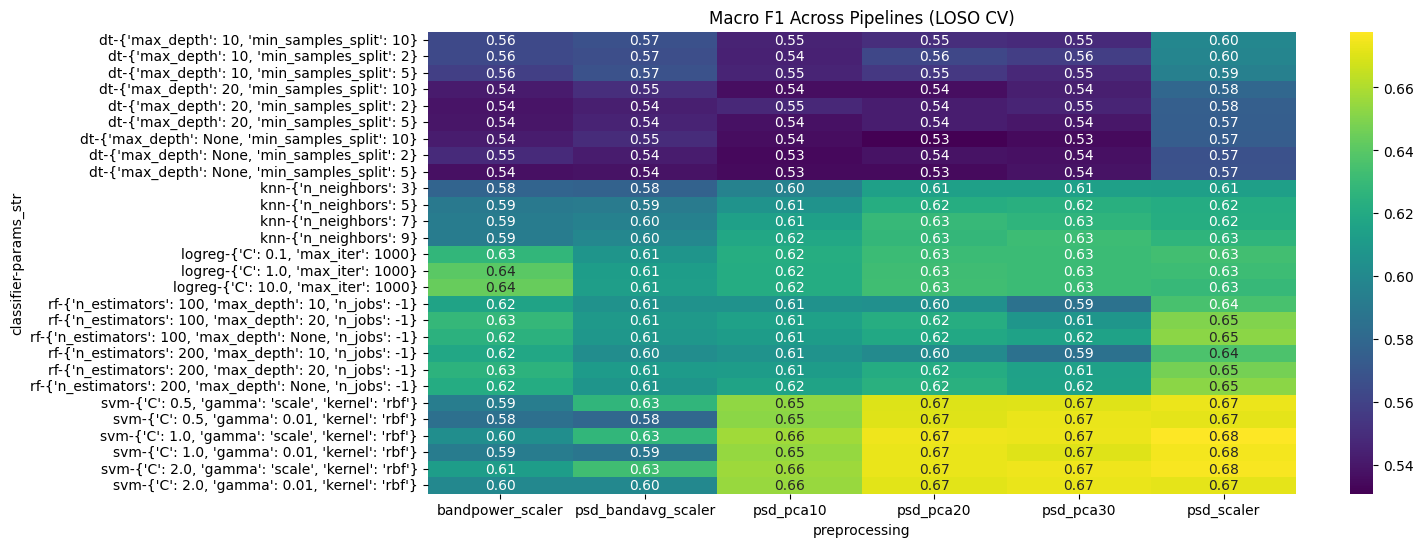

In [53]:
# deliverable 3 - visualize results

cv_df['params_str'] = cv_df['params'].astype(str)

plt.figure(figsize=(14, 6))
sns.heatmap(
    cv_df.pivot_table(
        values="f1_macro_mean",
        index=["classifier", "params_str"],
        columns="preprocessing"
    ),
    cmap="viridis",
    annot=True,
    fmt=".2f"
)
plt.title("Macro F1 Across Pipelines (LOSO CV)")
plt.show()

### Which is the best model and why?

Based on LOSO cross-validation, the best-performing pipeline was:

Preprocessing: psd_scaler where we have only scaling applied without dimensionality reduction

Classifier: Support Vector Machine with RBF kernel

Hyperparameters:
- C = 1.0
- gamma = 'scale'

This is the best model based on the highest macro F1 score across all tested configurations. The macro F1 was chosen because sleep staging is multi class and imbalanced problem. Macro F1 will ensure that all sleep stages contribute equally to the evaluation, preventing dominance by frequent classes. Since PSD features contain many frequency bins per epoch they are considered as high dimensional, and SVM works well with higher dimensional data. In high dimensions distance based methods like KNN become noisy and tree based methods struggle to find stable splits. SVMs work by finding a decision boundary that maximizes the margin which is also efective when the classes are not linearly separable and the number of features is large.


### Task 3 — Deploy the best model and test it on the held-out subjects

Goal: train the selected pipeline on the full training set and evaluate on subjects 15–19 (the held-out test set).

Deliverables:
- Retrain the chosen pipeline on the entire training set (subjects 0–14)
- Run predictions on each test subject (15–19).
- Display a normalized confusion matrix (subjects combined) and print a pandas-formatted (DataFrame) classification report.

Additional Questions:
- Are your results in-line with your expectations?
- Can you do anything based on these results to improve your model?


In [54]:
X_psd_test, y_test, groups_test = build_feature_matrix(
    SUBJECTS_TEST,
    PSD_all,
    y,
    feature_selector=lambda x: x[0]   # channel 0 (Fpz-Cz)
) # X_psd_test = (n_epochs_test, n_freq_bins)

X_bp_test, _, _ = build_feature_matrix(
    SUBJECTS_TEST,
    BANDPOWER_all,
    y
) # X_bp_test = (n_epochs_test, n_band_features)

X_psd_bandavg_test, _, _ = build_feature_matrix(
    SUBJECTS_TEST,
    PSD_BANDAVG_all,
    y
) # X_psd_bandavg_test = (n_epochs_test, 5)

In [55]:
# 2 -extract the best model from CV results
best_idx = cv_df["f1_macro_mean"].idxmax()
best_row = cv_df.loc[best_idx]
best_row


,24
preprocessing,psd_scaler
feature_type,psd
classifier,svm
params,"{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}"
accuracy_mean,0.790126
accuracy_std,0.132286
f1_macro_mean,0.677746
f1_macro_std,0.131731
f1_weighted_mean,0.782264
f1_weighted_std,0.129124


In [ ]:
# 3 - build final pipeline and train on subjects 0–14

best_prep = best_row["preprocessing"]
best_clf_name = best_row["classifier"]
best_params = best_row["params"]
feature_type = best_row["feature_type"]

if feature_type == "psd":
    X_train_final = X_psd_train
    X_test_final = X_psd_test
elif feature_type == "bandpower":
    X_train_final = X_bp_train
    X_test_final = X_bp_test
elif feature_type == "psd_bandavg":
    X_train_final = X_psd_bandavg_train
    X_test_final = X_psd_bandavg_test
else:
    raise ValueError(f"Unknown feature type: {feature_type}")

preproc_steps = preprocessing_configs[best_prep]["preproc"]

Estimator = classifier_configs[best_clf_name]["estimator"]
clf_best = Estimator(**best_params)

final_pipe = make_pipeline(
    *[step[1] for step in preproc_steps],
    clf_best
)

final_pipe.fit(X_train_final, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [57]:
# 4 - evaluate on held out
y_pred = final_pipe.predict(X_test_final)

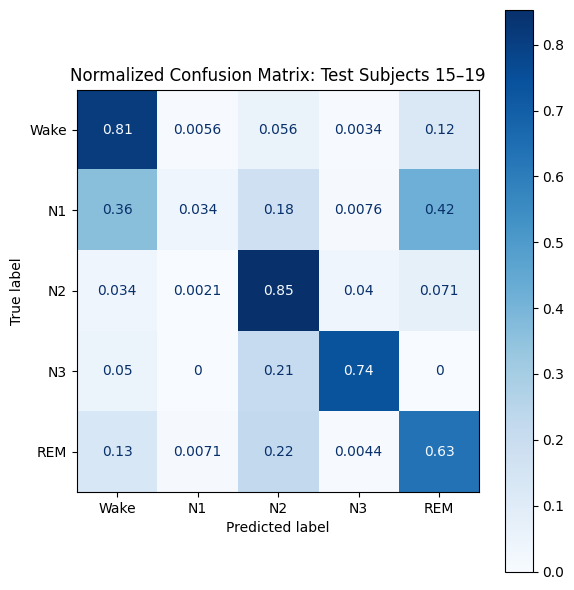

In [58]:
# normalized confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    display_labels=STAGES,
    cmap="Blues",
    ax=ax
)
plt.title("Normalized Confusion Matrix: Test Subjects 15–19")
plt.tight_layout()
plt.show()


In [59]:
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=STAGES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
report_df

,precision,recall,f1-score,support
Wake,0.659672,0.812360,0.728097,890.000000
N1,0.333333,0.034091,0.061856,264.000000
N2,0.783815,0.852829,0.816867,2351.000000
N3,0.872840,0.737996,0.799774,958.000000
REM,0.649186,0.633157,0.641071,1134.000000
accuracy,0.743613,0.743613,0.743613,0.743613
macro avg,0.659769,0.614086,0.609533,5597.000000
weighted avg,0.730787,0.743613,0.728595,5597.000000


## Additional questions

1.  Are the results in line with your expectations?
- Yes. The model achieves strong performance on dominant and well-defined sleep stages like N2, N3 and Wake, while it struggles with N1, which is known to be difficult to predict due to not having many characterisible patterns. The generalization gap between LOSO and the held out test set is moderate and expected for subject independent sleep staging using classical ML models.


2. Can anything be done to improve the model?
- Yes. We can improve performance by incorporating features from the EOG and EMG channels, which contain physiological information directly relevant for sleep staging. Including these signals as additional features could help the model better distinguish between stages with similar EEG patterns, particularly the N1 stage.

- Further imrpovements could be achieved by using class balanced learning, which will force the model to weight rare classes more and thus will improve recall for underrepresented stages like N1. Other improvement could be done by applying temporal smoothing accross consecutive epochs, this will use predictions of adjacent epochs to correct isolated misclassifications and produce more physiologically plausible staging. As another improvement could be done by utilizing sequence based models like hidden markov models that use temporal context directly into prediction, allowing the model to learn typical sleep stage transitions which will improve overall accuracy and consistency.